
# <span style="color:#336699">Introduction to the SpatioTemporal Asset Catalog (STAC)</span>
<hr style="border:2px solid #0077b9;">
<div style="text-align: left;">
    <a href="https://github.com/swisstopo/topo-satromo-v2/blob/main/codegallery/jupyter/Python/stac/stac-introduction.ipynb"><img src="https://img.shields.io/badge/View-GitHub-181717?logo=github" alt="View on GitHub"/></a>
    <a href="https://colab.research.google.com/github/swisstopo/topo-satromo-v2/blob/main/codegallery/jupyter/Python/stac/stac-introduction.ipynb"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>
</div>
   
<br/>

<b>Abstract.</b> This Jupyter Notebook gives an overview on how to use the data.geo.admin.ch STAC service to discover and access the data products of  <em>SwissEO</em>.


<br/>



# Introduction
<hr style="border:1px solid #0077b9;">

The [**S**patio**T**emporal **A**sset **C**atalog (STAC)](https://stacspec.org/) is a specification created through the colaboration of several organizations intended to increase satellite image search interoperability.

The diagram depicted in the picture contains the most important concepts behind the STAC data model:

<center>
<img src="../../../img/stac/stac-concept.png" width="480" />
<br/>
<b>Figure 1</b> - STAC model.
</center>

The description of the concepts below are adapted from the [STAC Specification](https://github.com/radiantearth/stac-spec):

- **Item**: a `STAC Item` is the atomic unit of metadata in STAC, providing links to the actual `assets` (including thumbnails) that they represent. It is a `GeoJSON Feature` with additional fields for things like time, links to related entities and mainly to the assets. According to the specification, this is the atomic unit that describes the data to be discovered in a `STAC Catalog` or `Collection`.

- **Asset**: a `spatiotemporal asset` is any file that represents information about the earth captured in a certain space and time.


- **Catalog**: provides a structure to link various `STAC Items` together or even to other `STAC Catalogs` or `Collections`.


- **Collection:** is a specialization of the `Catalog` that allows additional information about a spatio-temporal collection of data.

# STAC Client API
<hr style="border:1px solid #0077b9;">

For running the examples in this Jupyter Notebook you will need to install the [pystac-client](https://pystac-client.readthedocs.io/en/latest/). To install it from PyPI using `pip`, use the following command:

In [32]:
!pip install pystac-client


[notice] A new release of pip is available: 26.1.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [33]:
!pip install rasterio shapely matplotlib tqdm


[notice] A new release of pip is available: 26.1.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In order to access the funcionalities of the client API, you should import the `stac` package, as follows:

In [34]:
import pystac_client

After that, you can check the installed `stac` package version:

In [35]:
pystac_client.__version__

'0.9.0'

Then, create a `STAC` object attached to the data.geo.admin.ch STAC service:

In [36]:
service = pystac_client.Client.open('https://data.geo.admin.ch/api/stac/v0.9/')

Due to the "Swisstopo finish" STAC implementation,  we need to add the conformance classes: 

In [37]:
service.add_conforms_to("COLLECTIONS")
service.add_conforms_to("ITEM_SEARCH")

# Listing the Available <em>SwissEO</em> Data Products
<hr style="border:1px solid #0077b9;">

In the Jupyter environment, the `STAC` object will list the available <em> SwissEO</em> collections from the service:

In [38]:
for collection in service.get_collections():
    if "swisseo" in collection.id.lower():
        print(collection)

<CollectionClient id=ch.swisstopo.swisseo_ndvi_diff_v100>
<CollectionClient id=ch.swisstopo.swisseo_ndvi_z_v100>
<CollectionClient id=ch.swisstopo.swisseo_s2-sr_v100>
<CollectionClient id=ch.swisstopo.swisseo_s2-sr_v200>
<CollectionClient id=ch.swisstopo.swisseo_vhi_v100>
<CollectionClient id=ch.swisstopo.swisseo_vhi_v200>


<img src="../../../img/stac/stac-catalog.png?raw=true" align="right" width="300"/>

# Retrieving the Metadata of a Collection
<hr style="border:1px solid #0077b9;">

The `collection` method returns information about a given collection identified by its name. In this example we are retrieving information about the datacube collection `ch.swisstopo.swisseo_s2-sr_v200`:

In [39]:
collection = service.get_collection('ch.swisstopo.swisseo_s2-sr_v200')
collection

<CollectionClient id=ch.swisstopo.swisseo_s2-sr_v200>

<img src="../../../img/stac/stac-item.png?raw=true" align="right" width="300"/>

# Retrieving Items
<hr style="border:1px solid #0077b9;">

The `get_items` method returns the items of a given collection:

In [40]:
#collection.get_items()
item_count = sum(1 for _ in collection.get_items())
print(f"Number of items in the collection: {item_count}")

Number of items in the collection: 1766


Let's define a 'bbox' around Bern

In [41]:
BBOX_AOI= (7.364515, 46.868545, 7.535312, 46.999127)

In order to support filtering rules through the specification of a rectangle (`bbox`) or a date and time (`datatime`) criterias, use the `Client.search(**kwargs)`:

In [42]:

item_search = service.search(
    bbox=BBOX_AOI,
    datetime='2026-07-01/2026-08-01',
    collections=['ch.swisstopo.swisseo_s2-sr_v200']
)


The method `.search(**kwargs)` returns a `ItemSearch` representation which has handy methods to identify the matched results. For example, to check the number of items matched, use `.items()`:

In [43]:
items = list(item_search.items())
print(f"Found {len(items)} items")

Found 18 items


To iterate over the matched result, use `.items()` to traverse the list of items:

In [44]:
for item in item_search.items():
    print(item)

<Item id=2026-07-02t103021>
<Item id=2026-07-04t102701>
<Item id=2026-07-04t101559>
<Item id=2026-07-07t102559>
<Item id=2026-07-09t101601>
<Item id=2026-07-11t102041>
<Item id=2026-07-12t102601>
<Item id=2026-07-14t103041>
<Item id=2026-07-14t101559>
<Item id=2026-07-17t103029>
<Item id=2026-07-19t101601>
<Item id=2026-07-22t103031>
<Item id=2026-07-24t102701>
<Item id=2026-07-24t101559>
<Item id=2026-07-27t102559>
<Item id=2026-07-29t101601>
<Item id=2026-07-31t101701>
<Item id=2026-08-01t103031>


<img src="../../../img/stac/stac-asset.png?raw=true" align="right" width="300"/>

# Assets
<hr style="border:1px solid #0077b9;">

The assets with the links to the images, thumbnails or specific metadata files, can be accessed through the property `assets` (from a given item):

In [45]:
assets = item.assets

Then, from the assets it is possible to traverse or access individual elements:

In [46]:
for k in assets.keys():
    print(k)

swisseo_s2-sr_v200_mosaic_2026-08-01t103031_tci_10m.tif
swisseo_s2-sr_v200_mosaic_2026-08-01t103031_b09_60m.tif
swisseo_s2-sr_v200_mosaic_2026-08-01t103031_b01_60m.tif
swisseo_s2-sr_v200_mosaic_2026-08-01t103031_aot_60m.tif
swisseo_s2-sr_v200_mosaic_2026-08-01t103031_scl_20m.tif
swisseo_s2-sr_v200_mosaic_2026-08-01t103031_b8a_20m.tif
swisseo_s2-sr_v200_mosaic_2026-08-01t103031_b12_20m.tif
swisseo_s2-sr_v200_mosaic_2026-08-01t103031_b11_20m.tif
swisseo_s2-sr_v200_mosaic_2026-08-01t103031_b07_20m.tif
swisseo_s2-sr_v200_mosaic_2026-08-01t103031_b06_20m.tif
swisseo_s2-sr_v200_mosaic_2026-08-01t103031_b05_20m.tif
swisseo_s2-sr_v200_mosaic_2026-08-01t103031_terrainmask_10m.tif
swisseo_s2-sr_v200_mosaic_2026-08-01t103031_cloudmask_10m.tif
swisseo_s2-sr_v200_mosaic_2026-08-01t103031_b08_10m.tif
swisseo_s2-sr_v200_mosaic_2026-08-01t103031_b04_10m.tif
swisseo_s2-sr_v200_mosaic_2026-08-01t103031_b03_10m.tif
swisseo_s2-sr_v200_mosaic_2026-08-01t103031_b02_10m.tif
swisseo_s2-sr_v200_mosaic_2026-08-

Starting with <em>SwissEO S2-SR v200</em>, the asset naming convention is: each spectral band is delivered as an individual single-band Cloud Optimized GeoTIFF. Asset keys follow the pattern `swisseo_s2-sr_v200_mosaic_<timestamp>_<band>_<resolution>.tif`, with bands `b01` (Coastal aerosol, 60m), `b02` (Blue, 10m), `b03` (Green, 10m), `b04` (Red, 10m), `b05`-`b07` (Red edge, 20m), `b08` (NIR, 10m), `b8a` (NIR narrow, 20m), `b09` (Water vapour, 60m), `b11`-`b12` (SWIR, 20m), plus derived /additional assets `aot`, `tci`, `cloudmask`, `terrainmask`, `scl` and `metadata.json`.

To retrieve the Red band (`b04`) at 10m resolution, look for the dictionary key which ends with `b04_10m.tif`:

In [47]:
asset_key = next((key for key in assets.keys() if key.endswith('b04_10m.tif')), None)
red_band_asset = assets[asset_key]
red_band_asset


<Asset href=https://data.geo.admin.ch/ch.swisstopo.swisseo_s2-sr_v200/2026-08-01t103031/swisseo_s2-sr_v200_mosaic_2026-08-01t103031_b04_10m.tif>

To iterate in the item's assets, use the following pattern:

In [48]:
for asset in assets.values():
    print(asset)

<Asset href=https://data.geo.admin.ch/ch.swisstopo.swisseo_s2-sr_v200/2026-08-01t103031/swisseo_s2-sr_v200_mosaic_2026-08-01t103031_tci_10m.tif>
<Asset href=https://data.geo.admin.ch/ch.swisstopo.swisseo_s2-sr_v200/2026-08-01t103031/swisseo_s2-sr_v200_mosaic_2026-08-01t103031_b09_60m.tif>
<Asset href=https://data.geo.admin.ch/ch.swisstopo.swisseo_s2-sr_v200/2026-08-01t103031/swisseo_s2-sr_v200_mosaic_2026-08-01t103031_b01_60m.tif>
<Asset href=https://data.geo.admin.ch/ch.swisstopo.swisseo_s2-sr_v200/2026-08-01t103031/swisseo_s2-sr_v200_mosaic_2026-08-01t103031_aot_60m.tif>
<Asset href=https://data.geo.admin.ch/ch.swisstopo.swisseo_s2-sr_v200/2026-08-01t103031/swisseo_s2-sr_v200_mosaic_2026-08-01t103031_scl_20m.tif>
<Asset href=https://data.geo.admin.ch/ch.swisstopo.swisseo_s2-sr_v200/2026-08-01t103031/swisseo_s2-sr_v200_mosaic_2026-08-01t103031_b8a_20m.tif>
<Asset href=https://data.geo.admin.ch/ch.swisstopo.swisseo_s2-sr_v200/2026-08-01t103031/swisseo_s2-sr_v200_mosaic_2026-08-01t10303

# Using RasterIO and NumPy
<hr style="border:1px solid #0077b9;">

The `rasterio` library can be used to read image files from the data.geo.admin.ch service on-the-fly and then to create `NumPy` arrays. The `read` method of an `Item` can be used to perform the reading and array creation:

In [49]:

import rasterio


We will work with a subset and define the extent in 'BBOX_AOI_LV95', since <em> SwissEO</em> data is in 'EPSG:2056' aka 'LV95' projection

In [50]:
BBOX_AOI_LV95 = (2594452.12, 1195764.73, 2599109.31, 1199129.62)

Since in v200 the RED, GREEN, BLUE and NIR bands are stored in separate files, we look up the four asset keys (`b04_10m` for RED, `b03_10m` for GREEN, `b02_10m` for BLUE, `b08_10m` for NIR) and open each `rasterio` dataset individually, using its `.window()` method to retrieve only the pixels overlapping `BBOX_AOI_LV95`:

In [51]:

red_key = next((key for key in assets.keys() if key.endswith('b04_10m.tif')), None)
green_key = next((key for key in assets.keys() if key.endswith('b03_10m.tif')), None)
blue_key = next((key for key in assets.keys() if key.endswith('b02_10m.tif')), None)
nir_key = next((key for key in assets.keys() if key.endswith('b08_10m.tif')), None)

with rasterio.open(assets[red_key].href) as src:
    window = src.window(*BBOX_AOI_LV95)
    red = src.read(1, window=window)

with rasterio.open(assets[green_key].href) as src:
    window = src.window(*BBOX_AOI_LV95)
    green = src.read(1, window=window)

with rasterio.open(assets[blue_key].href) as src:
    window = src.window(*BBOX_AOI_LV95)
    blue = src.read(1, window=window)

with rasterio.open(assets[nir_key].href) as src:
    window = src.window(*BBOX_AOI_LV95)
    nir = src.read(1, window=window)

<div style="text-align: justify;  margin-left: 15%; margin-right: 15%; border-style: solid; border-color: #0077b9; border-width: 1px; padding: 5px;">
    <b>Note:</b> If there are errors because of your pyproj version, you can run the code below as specified in <a  href="https://rasterio.readthedocs.io/en/latest/faq.html#why-can-t-rasterio-find-proj-db-rasterio-from-pypi-versions-1-2-0" target="_blank">rasterio documentation</a> and try again:

       import os
       del os.environ['PROJ_LIB']
</div>

In [52]:
nir

array([[2675, 2907, 2526, ..., 1980, 2046, 2375],
       [2698, 2901, 2504, ..., 1893, 2099, 2432],
       [2675, 2762, 2366, ..., 1782, 1979, 2221],
       ...,
       [5796, 5854, 5858, ..., 8027, 8295, 8436],
       [5577, 5609, 5639, ..., 8148, 8358, 8432],
       [5344, 5343, 5341, ..., 8275, 8404, 8409]],
      shape=(336, 466), dtype=uint16)

For <em>SwissEO S2-SR v200</em>, pixel values follow the Sentinel-2 processing baseline &ge; 04.00 convention: they are scaled <b>and</b> offset. To obtain the actual reflectance value, apply `reflectance = pixel_value * 0.0001 - 0.1`:

In [53]:
scale = 0.0001
offset = -0.1

red = red * scale + offset
green = green * scale + offset
blue = blue * scale + offset

To enhance the contrast, we set reflectance values greater than 0.14 to 0.14, for this we need numpy

In [54]:
import numpy 

In [55]:
red = numpy.clip(red, 0, 0.14)
green = numpy.clip(green, 0, 0.14)
blue = numpy.clip(blue, 0, 0.14)


# Using Matplotlib to Visualize Images
<hr style="border:1px solid #0077b9;">

The `Matplotlib` cab be used to plot the arrays read in the last section:

In [56]:
%matplotlib inline
from matplotlib import pyplot as plt

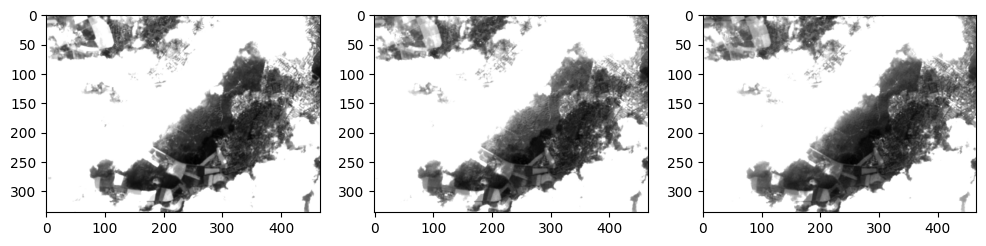

In [57]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(12, 4))
ax1.imshow(red, cmap='gray')
ax2.imshow(green, cmap='gray')
ax3.imshow(blue, cmap='gray')

Using `Numpy` we can stack the previous arrays and use `Matplotlib` to plot a color image, but first we need to normalize their values:

In [58]:
def normalize(array):
    """Normalizes numpy arrays into scale 0.0 - 1.0"""
    array_min, array_max = array.min(), array.max()
    return ((array - array_min)/(array_max - array_min))

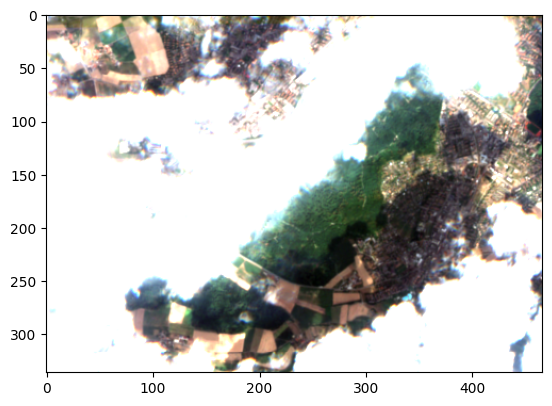

In [59]:
rgb = numpy.dstack((normalize(red), normalize(green), normalize(blue)))
plt.imshow(rgb)

# Retrieving Image Files
<hr style="border:1px solid #0077b9;">

<div style="text-align: justify;  margin-left: 15%; margin-right: 15%; border-style: solid; border-color: #0077b9; border-width: 1px; padding: 5px;">
    <b>Note:</b> Since <em>SwissEO</em> products are provided in cloud-native geospatial formats, such as <a href="https://cloudnativegeo.org" target="_blank">Cloudnative Geo Data</a>, including <a href="https://cogeo.org/" target="_blank">Cloud Optimized GeoTIFF</a> and <a href="https://geoparquet.org/" target="_blank">GeoParquet</a>, we strongly recommend leveraging these formats to stream data directly into your applications. This approach ensures that you are always working with the latest version of the data. Keep in mind: <a href="https://digital.ebp.ch/2014/03/31/services-or-raw-data/" target="_blank">everything is a cache unless you own the data.</a> Now, if you still really want to download the data: follow the instructions below...
</div>

The file related to an asset can be retrieved through the `download` method. The cell code below shows ho to download the image file associated to the asset into a folder named `img`:

In [60]:
# import os
# from urllib.parse import urlparse

# import requests
# from pystac import Asset
# from tqdm import tqdm

# def download(asset: Asset, directory: str = None, chunk_size: int = 1024 * 16, **request_options) -> str:
#     """Smart download STAC Item asset.

#     This method uses a checksum validation and a progress bar to monitor download status.
#     """
#     if directory is None:
#         directory = ''

#     response = requests.get(asset.href, stream=True, **request_options)
#     output_file = os.path.join(directory, urlparse(asset.href)[2].split('/')[-1])
#     os.makedirs(directory, exist_ok=True)
#     total_bytes = int(response.headers.get('content-length', 0))
#     with tqdm.wrapattr(open(output_file, 'wb'), 'write', miniters=1, total=total_bytes, desc=os.path.basename(output_file)) as fout:
#         for chunk in response.iter_content(chunk_size=chunk_size):
#             fout.write(chunk)

In [61]:
# download(assets[asset_key], 'img')

In order to download all files related to an item, iterate over assets and download each one as following:

In [62]:
# for asset in assets.values():
#      download(asset, 'images')

# References
<hr style="border:1px solid #0077b9;">

- [Spatio Temporal Asset Catalog Specification](https://stacspec.org/)


- [Python Client Library for STAC Service](https://pystac-client.readthedocs.io/en/latest/)

# See also the following Jupyter Notebooks
<hr style="border:1px solid #0077b9;">

* [Image processing on images obtained through STAC](./stac-image-processing.ipynb)

<small><b>Acknowledgments</b>:
This Jupyter Notebook was inspired by the code gallery tutorial from the [Brazil Data Cube Code Gallery](https://github.com/brazil-data-cube/code-gallery/). Special thanks to their open-source contributions and educational resources that helped shape this tutorial.</small>